In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

import matplotlib.pyplot as plt

sys.path.append('/users/odarwish/abacusutils/')

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

In [2]:
import numpy as np
import numba

@numba.njit(parallel=True)
def calc_power_mu0_x_axis(delta_k, BoxSize, k_bin_edges = np.logspace(np.log10(1e-3), np.log10(0.5), 200), delta_k2 = None):
    """
    Compute the μ=0 power spectrum (perpendicular to x-axis) from a 3D Fourier field
    
    Parameters
    ----------
    delta_k : array_like
        Complex 3D Fourier field of shape (n1d, n1d, n1d//2+1)
    BoxSize : float
        Physical size of the simulation box
    k_bin_edges : array_like
        Edges of the k bins for binning the power spectrum
        
    Returns
    -------
    k_values : ndarray
        Mean k values in each bin
    power : ndarray
        Power spectrum for modes perpendicular to x-axis (μ=0)
    nmodes : ndarray
        Number of modes in each bin
    """
    if delta_k2 is None:
        delta_k2 = delta_k
        
    # Get dimensions
    n1d = delta_k.shape[0]
    middle = n1d // 2
    kzlen = n1d // 2 + 1
    
    # Fundamental mode
    kF = 2.0 * np.pi / BoxSize
    
    # Set up arrays for results
    Nk = len(k_bin_edges) - 1
    k_values = np.zeros(Nk, dtype=np.float64)
    power = np.zeros(Nk, dtype=np.float64)
    nmodes = np.zeros(Nk, dtype=np.int64)
    
    # Convert bin edges to grid units
    kedges = np.zeros_like(k_bin_edges)
    for i in range(len(k_bin_edges)):
        kedges[i] = k_bin_edges[i] / kF
    
    # Loop over all independent modes in the Fourier grid
    for kxx in numba.prange(n1d):
        # Convert array index to k-space value
        kx = kxx - n1d if kxx > middle else kxx
        
        # For μ=0 with x-axis as line of sight, we need kx=0
        if kx != 0:
            continue
            
        for kyy in range(n1d):
            ky = kyy - n1d if kyy > middle else kyy
            
            for kzz in range(kzlen):
                kz = kzz  # kz is always positive due to rfft
                
                # Handle symmetry planes
                if kz == 0 or (kz == middle and n1d % 2 == 0):
                    if ky < 0:
                        continue
                    elif ky == 0 or (ky == middle and n1d % 2 == 0):
                        if kz < 0:
                            continue
                
                # Compute |k| of the mode for binning
                k_perp = np.sqrt(ky*ky + kz*kz)
                
                # Find the bin for this k value
                bin_idx = -1
                for b in range(Nk):
                    if k_perp >= kedges[b] and k_perp < kedges[b+1]:
                        bin_idx = b
                        break
                
                if bin_idx >= 0:
                    # Compute the power
                    #mode_power = np.abs(delta_k[kxx, kyy, kzz])**2
                    mode_power = np.real(delta_k[kxx, kyy, kzz] * np.conj(delta_k2[kxx, kyy, kzz]))
                    
                    # Account for complex conjugate modes
                    mode_count = 1 if (kz == 0 or (kz == middle and n1d % 2 == 0)) else 2
                    
                    # Add to the bin
                    nmodes[bin_idx] += mode_count
                    power[bin_idx] += mode_power * mode_count
                    k_values[bin_idx] += k_perp * kF * mode_count
    
    # Normalize the results
    for i in range(Nk):
        if nmodes[i] > 0:
            power[i] = power[i] / nmodes[i] * BoxSize**3  # Proper units
            k_values[i] = k_values[i] / nmodes[i]
    
    return k_values, power#, nmodes

In [3]:
from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path

In [18]:
out_normalization_AB.keys()

dict_keys([('n', 'n'), ('s', 'n'), ('n', 's'), ('g', 'n'), ('n', 'g'), ('t', 'n'), ('n', 't'), ('g', 'g'), ('s', 's'), ('t', 't'), ('g', 's'), ('s', 'g'), ('g', 't'), ('t', 'g'), ('s', 't'), ('t', 's'), ('n', 'ga'), ('ga', 'n'), ('n', 'sa'), ('sa', 'n'), ('n', 'ta'), ('ta', 'n')])

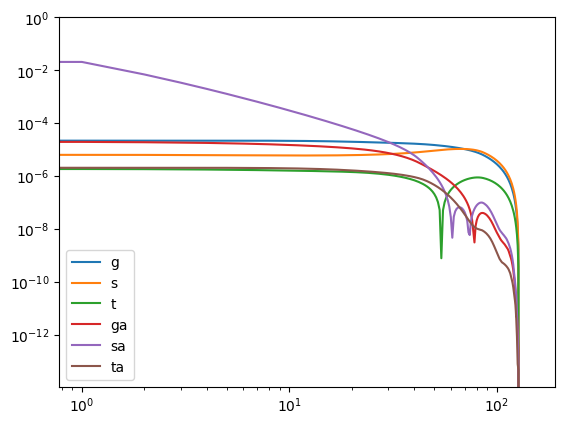

In [21]:
keys = ["g", "s", "t", "ga", "sa", "ta"]
key = "n"
colors = {"g": green, "s": blue, "t": brown}
for k in keys:
    R = out_normalization_AB[(key, k)]
    plt.loglog(abs(R), label = k)
plt.legend()

In [4]:
scratch = "/capstor/scratch/cscs/odarwish/ABACUS/"

In [5]:
z = 0.5

In [6]:
pos = np.load(scratch+"pos_file.npy")

In [7]:
Nparticles = pos.shape

In [8]:
Nparticles

(9610891666,)

In [9]:
box = 2000
nthread = 256
ngrid = 576#*2

In [10]:
interlaced = True
compensated = True
paste = 'TSC'
nbins_mu = 4
logk = False
k_hMpc_max = np.pi * ngrid / box + 1.0e-6
nbins_k = ngrid // 2
nthread = 128
dtype = np.float32

In [17]:
with open('config_abacus.yaml', 'r') as f:
    config = yaml.safe_load(f)
gen_nl_power = np.loadtxt(config['power_spectrum']['nonlinear'])

In [12]:
from abacusnbody.analysis import tsc
delta = tsc.tsc_parallel(pos['pos'], ngrid, box, nthread=nthread)
delta /= np.mean(delta, dtype=np.float64)
delta -= 1.

In [13]:
#delta_shifted = tsc.tsc_parallel(pos['pos']+box/2, ngrid, box, nthread=nthread)
#delta_shifted /= np.mean(delta_shifted, dtype=np.float64)
#delta_shifted -= 1.

In [14]:
del pos

In [15]:
#del delta_shifted

In [6]:
from scipy.fft import rfftn, irfftn, fftfreq, rfftfreq
def get_kgrid(N):
    return 2 * np.pi * np.stack(
        np.meshgrid(
            fftfreq(N, d=box/N), fftfreq(N, d=box/N), rfftfreq(N, d=box/N),
            indexing='ij',
            )
        )

In [17]:
1/(2 * np.pi*box/ngrid), np.pi*ngrid/(2*box), 2*np.pi/box

(0.04583662361046586, 0.4523893421169302, 0.0031415926535897933)

In [18]:
#k = (fftfreq(nmesh, d=d) * 2.0 * np.pi).astype(np.float32)  # h/Mpc

W = ps.get_W_compensated(box, ngrid, paste, interlaced)
f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
)

In [19]:
kgrid = get_kgrid(delta.shape[0])
print(kgrid.shape)
kmag = (kgrid**2).sum(axis=0)**0.5
print(kmag.shape)

(3, 576, 576, 289)
(576, 576, 289)


In [20]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)
field_fft *= 1 / delta.size

In [21]:
inv_size = dtype(1 / delta.size)
field_fft = rfftn(delta, overwrite_x=True, workers=nthread)
ps._normalize(field_fft, inv_size, nthread=nthread)
field_fft /= (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
)

In [14]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

In [8]:
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp

sim_name = config['sim_params']['sim_name']
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)

z_ic = meta['InitialRedshift']

Dz = meta['GrowthTable']
ztarget = 0.5
zpk = meta['ZD_Pk_file_redshift']  # 1.0
pk = meta['CLASS_power_spectrum']
k  = pk['k (h/Mpc)']
input_pk = pk['P (Mpc/h)^3']
linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2

gen_power = np.loadtxt(config['power_spectrum']['linear'])


In [9]:
D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic]
D_ratio

59.91148545808563

In [25]:
sim_name = config['sim_params']["sim_name"]
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)
del ic

In [26]:
ic = load_dens(ic_dir, sim_name, ngrid)
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size
del ic

In [15]:
#ic = load_dens(ic_dir, sim_name, ngrid)

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
gen_power = np.loadtxt(config['power_spectrum']['linear'])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']

In [16]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()


kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

In [ ]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)
#field_fft *= 1 / delta.size

In [30]:
ff = lambda size: np.exp(1j*np.random.uniform(0., 2.*np.pi, size = size))
field_fft_rand = field_fft*ff(field_fft.size).reshape(field_fft.shape)
field_fft_rand[0, 0, 0] = 0

In [31]:
#field_shifted_fft = rfftn(delta_shifted, overwrite_x=False, workers=nthread)

In [32]:
import rec_utils as utils, rec

In [33]:
Ptot_interp = np.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
gen_power = np.loadtxt(config['power_spectrum']['linear'])
Plin_interp = np.interp(kmag, gen_power[:,0], gen_power[:,1])

In [34]:
def get_shift_n_rec(real_field, box = 2000, kmin = 0, kmax = 0, Ptot_interp = None, Plin_interp = None, nthread = 128):

    fft_field = rfftn(real_field, overwrite_x = False, workers = nthread)
    N = real_field.shape[0]
    kgrid, kmag = utils.get_kgrid_kmag(box, N)

    selection = (kmag>=kmin) & (kmag<=kmax)
    #selection = gauss_filter(kmag)

    delta_A = fft_field*1/Ptot_interp*selection #IVF FIELD
    delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)

    delta_B = fft_field*1/Ptot_interp*Plin_interp*selection #WF FIELD

    inv_kmag_2 = 1/kmag**2
    inv_kmag_2[kmag == 0] = 0


    j_factor = 1j
    
    term = 0.
    tot_1 = 0.
    tot_2 = 0.
    for i in range(3):
        term_2 = delta_B*j_factor*(-kgrid[i])
        term_2_real = irfftn(term_2, overwrite_x=True, workers=nthread)

        product_2 = term_2_real*delta_A_real
        term_2 = rfftn(product_2, overwrite_x=False, workers=nthread)
        term_2 *= j_factor*kgrid[i]*inv_kmag_2

        term += (term_2)*delta_A_real.size

    return term*0.5

In [35]:
ic = load_dens(ic_dir, sim_name, ngrid)
shift_n_rec_linear = get_shift_n_rec(ic*D_ratio/ic.size, box, kmin, kmax, Ptot_interp, Plin_interp)
k_values, shift_n_power_linear = calc_power_mu0_x_axis(
    shift_n_rec_linear,     # Your FFT field
    BoxSize=box,   # Box size
    #k_bin_edges=k_bin_edges
)

/tmp/ipykernel_235033/2565567020.py:15: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


In [36]:
with open('config_abacus_check.yaml', 'r') as f:
    config = yaml.safe_load(f)

out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()

Ptot_interp = np.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])

Ptot_interp_A = Ptot_interp*config['bias']['b10_A']**2+1/float(config['number_density']['nbar_A'])
Ptot_interp_B = Ptot_interp*config['bias']['b10_B']**2+1/float(config['number_density']['nbar_B'])

field_A = ic*D_ratio/ic.size*config['bias']['b10_A']
field_B = ic*D_ratio/ic.size*config['bias']['b10_B']

#field_A = delta*config['bias']['b10_A']/delta.size
#field_B = delta*config['bias']['b10_B']/delta.size

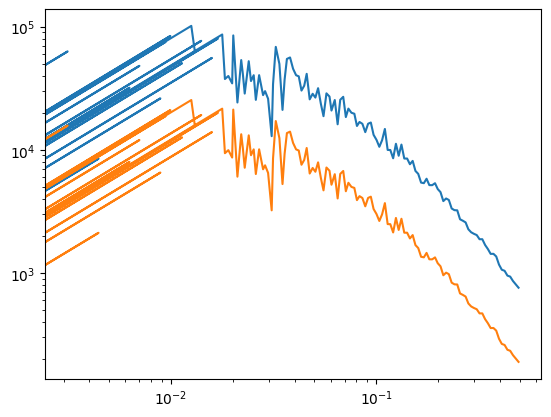

In [38]:
fft_field_A = rfftn(field_A, overwrite_x = False, workers = nthread)
fft_field_B = rfftn(field_B, overwrite_x = False, workers = nthread)


k_values, p = calc_power_mu0_x_axis(
    fft_field_A,     # Your FFT field
    BoxSize=box,   # Box size
)
plt.loglog(k_values, p)

k_values, p = calc_power_mu0_x_axis(
    fft_field_B,     # Your FFT field
    BoxSize=box,   # Box size
)
plt.loglog(k_values, p)

In [82]:
def shift_single(WF, IVF_real, j_factor, ki, inv_kmag_2, nthread):
    term_WA_B = WF*j_factor*(-ki)
    term_WA_B_real = irfftn(term_WA_B, overwrite_x=True, workers=nthread)
    product_WA_B = term_WA_B_real#*IVF_real
    product_WA_B_fft = rfftn(product_WA_B, overwrite_x=False, workers=nthread)
    #product_WA_B_fft *= j_factor*ki*inv_kmag_2
    return product_WA_B_fft


W = ps.get_W_compensated(box, ngrid, paste, interlaced)
f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
)

def get_shift_n_rec(real_field, box = 2000, kmin = 0, kmax = 0, Ptot_interp = None, Plin_interp = None, nthread = 128, real_field_2 = None, Ptot_interp_2 = None):

    fft_field = rfftn(real_field, overwrite_x = False, workers = nthread)/f

    fft_field_2 = rfftn(real_field_2, overwrite_x = False, workers = nthread)/f

    N = real_field.shape[0]
    kgrid, kmag = utils.get_kgrid_kmag(box, N)

    selection = (kmag>=kmin) & (kmag<=kmax)

    delta_A_ivf = fft_field*1/Ptot_interp*selection #IVF FIELD A
    #delta_A_ivf_real = irfftn(delta_A_ivf, overwrite_x=True, workers=nthread)
    delta_A_WF = delta_A_ivf*Plin_interp

    delta_B_ivf = fft_field_2*1/Ptot_interp_2*selection #IVF FIELD B
    delta_B_ivf_real = irfftn(delta_B_ivf, overwrite_x=True, workers=nthread)
    #delta_B_WF = delta_B_ivf*Plin_interp

    inv_kmag_2 = 1/kmag**2
    inv_kmag_2[kmag == 0] = 0

    j_factor = 1j
    
    term = 0.
    for i in range(1):
        
        product_WA_B_fft = shift_single(delta_A_WF, delta_B_ivf_real, j_factor, kgrid[i], inv_kmag_2, nthread)

        total = (product_WA_B_fft)
        term += (total)*delta_B_ivf_real.size

    return term*0.5

In [83]:
field_n = get_shift_n_rec(field_A, box, kmin, kmax, Ptot_interp_A, Plin_interp, real_field_2 = field_B, Ptot_interp_2 = Ptot_interp_B)

/tmp/ipykernel_235033/3974938239.py:37: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


2.631700578185872e-29


In [ ]:
field_n_2 = get_shift_n_rec(field_B, box, kmin, kmax, Ptot_interp_B, Plin_interp, real_field_2 = field_A, Ptot_interp_2 = Ptot_interp_A)

In [ ]:
#large_scale_bins = np.linspace(1e-3, 5e-3, 3)
small_scale_bins = np.logspace(np.log10(1e-3), np.log10(1), 80)
small_scale_bins = np.linspace(1e-4, 1, 100)

k_bin_edges_default = np.unique(np.concatenate([small_scale_bins]))

k_values, power_n = calc_power_mu0_x_axis(
    field_n,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges_default
)


k_values, power_n_2 = calc_power_mu0_x_axis(
    field_n_2,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges_default
)

key = "n"
kinds = ["s", "t", "g"]
N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

#plt.plot(k_values, shift_n_power_linear)

plt.loglog(k_values, power_n/power_n_2, ls = "--")
#plt.plot(k_values, power_n_2, ls = "--")

#plt.plot(k_values, 1/k_values**2*1e-9)

#plt.loglog(Ks, N**-1)
#plt.loglog(Ks, v, ls = "--", lw = 2)

#plt.ylim(1e-8, 1e-3)
plt.xlim(6e-3, 2e-1)

#plt.ylim(1, 1e3)
#plt.plot(k_values, 1/k_values**4*1e-3)

In [63]:
growth_rec = rec.get_growth_rec(delta, box, kmin, kmax, Ptot_interp, Plin_interp)
k_values, growth_power = calc_power_mu0_x_axis(
    growth_rec,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

In [64]:
growth_rec_shifted = rec.get_growth_rec(delta_shifted, box, kmin, kmax, Ptot_interp, Plin_interp)
k_values, growth_shifted_power = calc_power_mu0_x_axis(
    growth_rec_shifted,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

k_values, growth_shifted_power_cross = calc_power_mu0_x_axis(
    growth_rec_shifted,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges,
    delta_k2 = ic_fft.astype(np.complex128)*D_ratio
)

In [65]:
shift_rec = rec.get_shift_rec(delta, box, kmin, kmax, Ptot_interp, Plin_interp)
k_values, shift_power = calc_power_mu0_x_axis(
    shift_rec,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

/users/odarwish/colabdata/rec.py:98: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


In [66]:
shift_rec_shifted = rec.get_shift_rec(delta_shifted, box, kmin, kmax, Ptot_interp, Plin_interp)
k_values, shift_shifted_power = calc_power_mu0_x_axis(
    shift_rec_shifted,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

k_values, shift_shifted_power_cross = calc_power_mu0_x_axis(
    shift_rec_shifted,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges,
    delta_k2 = ic_fft.astype(np.complex128)*D_ratio
)

In [67]:
tidal_rec = rec.get_tidal_rec(delta, box, kmin, kmax, Ptot_interp, Plin_interp)
k_values, tidal_power = calc_power_mu0_x_axis(
    tidal_rec,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

/users/odarwish/colabdata/rec.py:67: RuntimeWarning: invalid value encountered in divide
  delta_B = fft_field*1/Ptot_interp*Plin_interp*selection*(kgrid[i]/kmag)*(kgrid[j]/kmag)
/users/odarwish/colabdata/rec.py:73: RuntimeWarning: invalid value encountered in divide
  term *= (kgrid[i]/kmag)*(kgrid[j]/kmag)


In [68]:
tidal_rec_shifted = rec.get_tidal_rec(delta_shifted, box, kmin, kmax, Ptot_interp, Plin_interp)
k_values, tidal_shifted_power = calc_power_mu0_x_axis(
    tidal_rec_shifted,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

k_values, tidal_shifted_power_cross = calc_power_mu0_x_axis(
    tidal_rec_shifted,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges,
    delta_k2 = ic_fft.astype(np.complex128)*D_ratio
)

In [70]:
ic = load_dens(ic_dir, sim_name, ngrid)
shift_n_rec_linear = get_shift_n_rec(ic*D_ratio/ic.size, box, kmin, kmax, Ptot_interp, Plin_interp)
k_values, shift_n_power_linear = calc_power_mu0_x_axis(
    shift_n_rec_linear,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

/tmp/ipykernel_258845/2565567020.py:15: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


(0.006, 0.2)

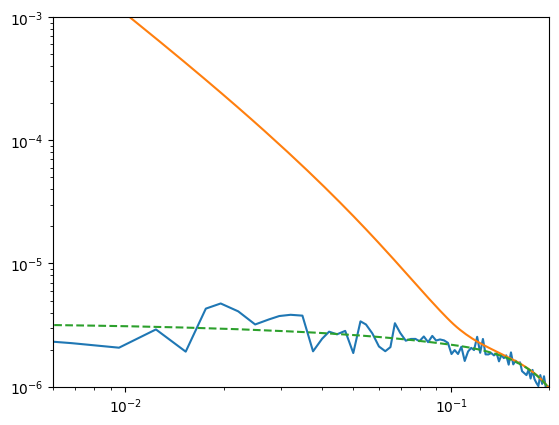

In [71]:
key = "n"
kinds = ["s", "t", "g"]
N = out_normalization_AB[(key, key)]**-1.
v = out_variance_AB[(key, key)]

plt.plot(k_values, shift_n_power_linear)

plt.loglog(Ks, N**-1)
plt.loglog(Ks, v, ls = "--")

plt.ylim(1e-6, 1e-3)
plt.xlim(6e-3, 2e-1)

In [72]:
shift_n_rec_shifted = get_shift_n_rec(delta_shifted, box, kmin, kmax, Ptot_interp, Plin_interp)

k_values, shift_n_shifted_power = calc_power_mu0_x_axis(
    shift_n_rec_shifted,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

k_values, shift_n_shifted_power_cross = calc_power_mu0_x_axis(
    shift_n_rec_shifted,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges,
    delta_k2 = ic_fft.astype(np.complex128)*D_ratio
)

/tmp/ipykernel_258845/2565567020.py:15: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


In [73]:
def plot(key, power, cross = False):
    non_linear_pk_interp = np.interp(Ks, gen_nl_power[:,0], gen_nl_power[:,1])
    
    N = out_normalization_AB[(key, key)]**-1.
    v = out_variance_AB[(key, key)]

    if not cross:
        plt.plot(Ks, N, label = "Normalization Noise")
        plt.plot(Ks, N**2*v, label = "Variance", ls = "--")
    
    factor = 1/delta.size**2
    
    bias = 0
    kinds = ["s", "t", "g"]
    for kk in kinds:
        bias += (N*out_normalization_AB[(key, kk)])
    
    linear_pk_interp = jnp.interp(Ks, k, linear_pk)
    if cross:
        plt.loglog(Ks, abs(bias)*linear_pk_interp, ls = "--")
    else:
        plt.loglog(Ks, bias**2*linear_pk_interp+N, ls = "--")
    
    a, b = k_values, power*factor**(1+int(cross==False))
    b[0] = 0.
    b = b.astype(float)
    value = np.interp(Ks, a, b)*N**(1+int(cross==False))
    plt.loglog(Ks, abs(value), ls = "--", label = "Reconstruction", color = "black")
    
    #plt.ylim(1e-6, 1)
    plt.xlim(2e-3, 2e-1)
    
    plt.legend()

    plt.show()

In [92]:
_, rec_alt = get_growth_rec(field_fft*f, return_field = True, real = False)

k_values, growth_power_alt = calc_power_mu0_x_axis(
    rec_alt*f**4,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

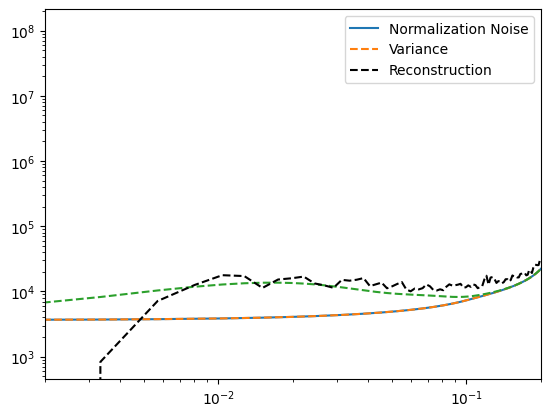

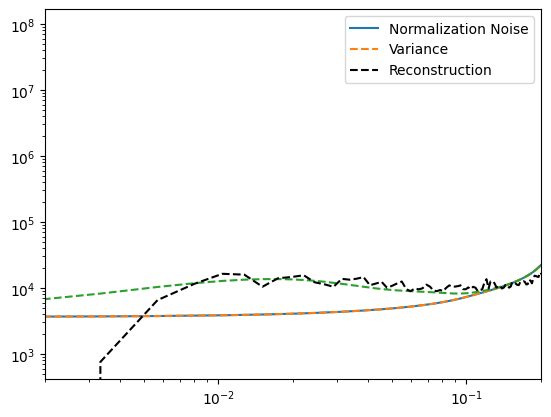

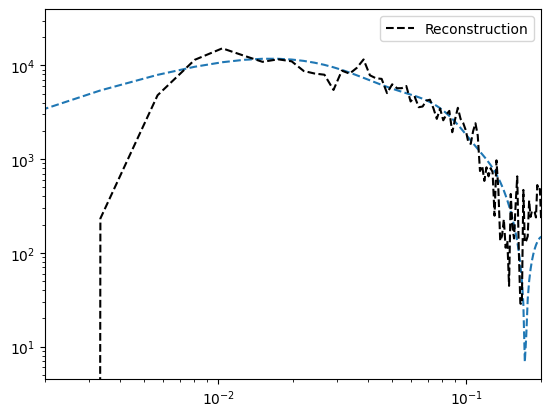

In [93]:
plot("g", growth_power)
plot("g", growth_power_alt)
plot("g", growth_shifted_power_cross, True)

In [98]:

def get_shift_rec(fft_field, box = 2000, kmin = 0, kmax = 0, Ptot_interp = None, Plin_interp = None, nthread = 128):

    #N = real_field.shape[0]
    #kgrid, kmag = utils.get_kgrid_kmag(box, N)

    selection = (kmag>=kmin) & (kmag<=kmax)
    #selection = gauss_filter(kmag)

    delta_A = fft_field*1/Ptot_interp*selection #IVF FIELD
    delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)

    delta_B = fft_field*1/Ptot_interp*Plin_interp*selection #WF FIELD

    inv_kmag_2 = 1/kmag**2
    inv_kmag_2[kmag == 0] = 0


    j_factor = 1j
    
    term = 0.

    for i in range(3):

        term_1 = delta_B*j_factor*(-kgrid[i])*inv_kmag_2
        term_2 = delta_B*j_factor*(-kgrid[i])

        term_1_real = irfftn(term_1, overwrite_x=True, workers=nthread)
        term_2_real = irfftn(term_2, overwrite_x=True, workers=nthread)
        
        product_1 = term_1_real*delta_A_real
        term_1 = rfftn(product_1, overwrite_x=False, workers=nthread)
        term_1 *= j_factor*kgrid[i]

        product_2 = term_2_real*delta_A_real
        term_2 = rfftn(product_2, overwrite_x=False, workers=nthread)
        term_2 *= j_factor*kgrid[i]*inv_kmag_2

        term += (term_1+term_2)*delta_A_real.size
    
    return term


rec_alt = get_shift_rec(field_fft*f, box, kmin, kmax, Ptot_interp, Plin_interp)

k_values, shift_power_alt = calc_power_mu0_x_axis(
    rec_alt*f**4,     # Your FFT field
    BoxSize=box,   # Box size
    k_bin_edges=k_bin_edges
)

/tmp/ipykernel_258845/2729012824.py:14: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


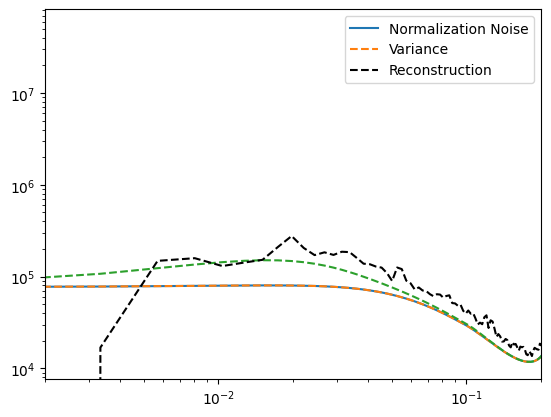

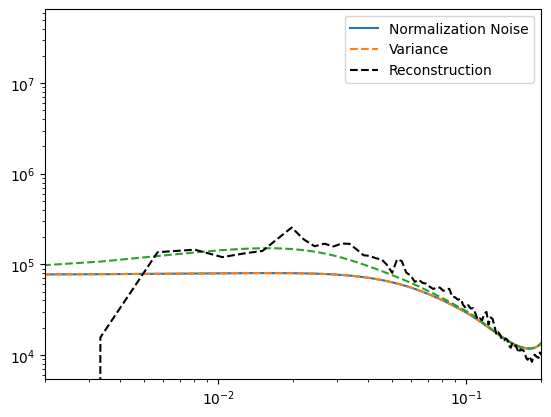

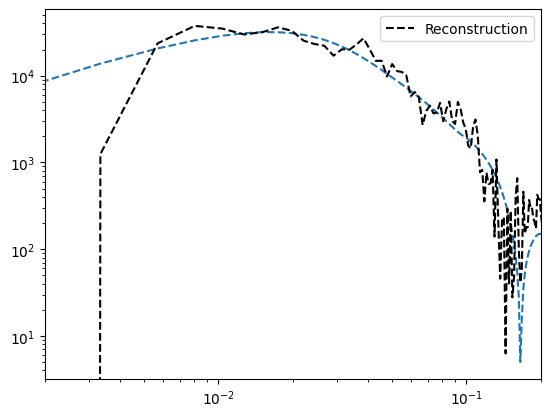

In [99]:
plot("s", shift_power)
plot("s", shift_power_alt)
plot("s", shift_shifted_power_cross, True)

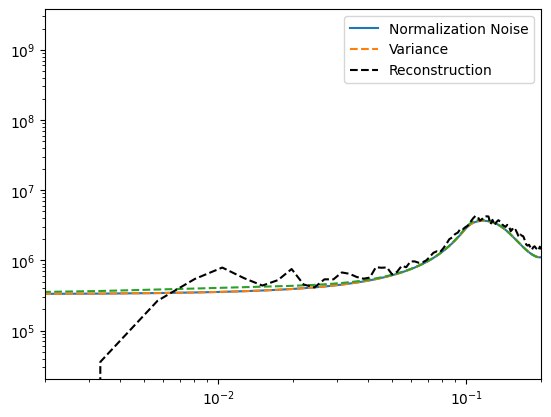

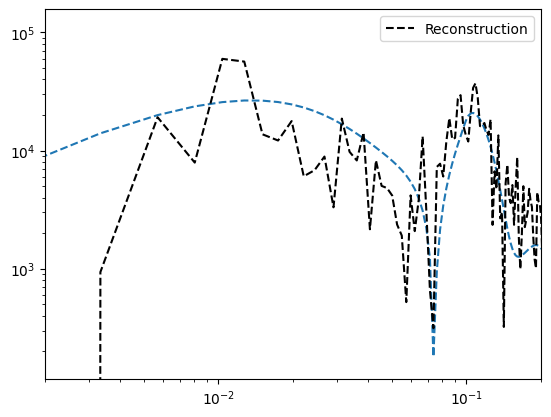

In [210]:
plot("t", tidal_power)
plot("t", tidal_shifted_power_cross, True)

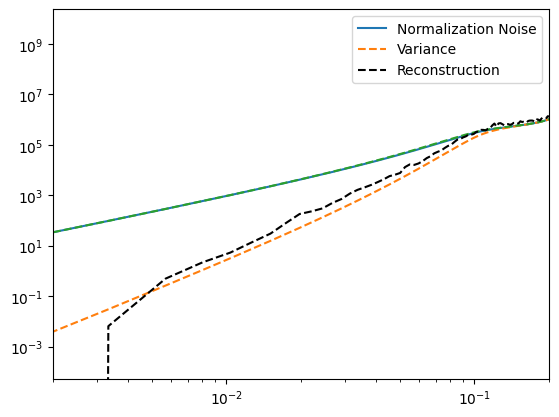

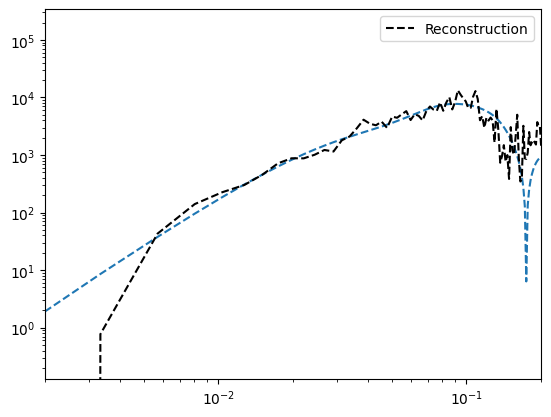

In [211]:
plot("n", shift_n_shifted_power)
plot("n", shift_n_shifted_power_cross, True)

In [103]:
box #Mpc/h

2000

In [73]:
box_Mpc = box*1
nbar = Nparticles[0]/box_Mpc**3

In [76]:
1/nbar, Nparticles[0]/1e9

(0.8323889476666586, 9.610891666)

In [ ]:
import jax
import jax.numpy as jnp

In [ ]:
kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']

get_gauss_filter = lambda R: (lambda K: np.exp(-K**2*R**2/2))
R = 1/kmax
gauss_filter = get_gauss_filter(R)

In [ ]:
delta_A = field_fft*1/Ptot_interp*selection
delta_B = field_fft*1/Ptot_interp*Plin_interp*selection

delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)

inv_kmag = np.nan_to_num(1/kmag)
inv_kmag[0, 0, 0] = 0

delta_1 = 0
for i in range(3):
    delta_1_i = kgrid[i]*inv_kmag**2*delta_A
    delta_A_real_i = irfftn(delta_1_i, overwrite_x=True, workers=nthread)
    temp_i = delta_A_real_i*delta_B_real
    fft_temp_i = rfftn(temp_i, overwrite_x=False, workers=nthread)
    fft_temp_i *= kgrid[i]
    delta_1 += fft_temp_i

delta_2 = 0
for i in range(3):
    delta_1_i = kgrid[i]*delta_A
    delta_A_real_i = irfftn(delta_1_i, overwrite_x=True, workers=nthread)
    temp_i = delta_A_real_i*delta_B_real
    fft_temp_i = rfftn(temp_i, overwrite_x=False, workers=nthread)
    fft_temp_i *= kgrid[i]*inv_kmag**2
    delta_2 += fft_temp_i

delta_final = -2*0.5*(delta_1+delta_2)

product_fft = delta_final#rfftn(delta_final, overwrite_x=False, workers=nthread)
#product_fft *= product.size

power_product_shift = calc_pk_from_deltak(
    product_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
from scipy.fft import rfftn, irfftn

inv_kmag2 = np.zeros_like(kgrid[0])
kmag2 = np.sum(kgrid**2, axis=0)
inv_kmag2[kmag2 > 0] = 1.0 / kmag2[kmag2 > 0]  # avoid div by 0

out_rfield = 0
for idir in range(3):
    k_i = kgrid[idir]
    
    # Psi_i(k) = -i * k_i * delta(k) / k^2
    Psi_i_k = -1j * k_i * field_fft * inv_kmag2
    Psi_i_x = irfftn(Psi_i_k, overwrite_x=True, workers=nthread)#*Psi_i_k.size

    # grad_i delta(k) = -i * k_i * delta(k)
    grad_i_k = -1j * k_i * field_fft
    grad_i_x = irfftn(grad_i_k, overwrite_x=True, workers=nthread)#*grad_i_k.size

    # Real-space product: Psi_i(x) * grad_i delta(x)
    out_rfield += Psi_i_x * grad_i_x

# Final result in Fourier space
out_fft = rfftn(out_rfield, overwrite_x=False, workers=nthread)
#out_fft /= out_fft.size

power_out = calc_pk_from_deltak(
    out_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
with open('config_abacus_2.yaml', 'r') as f:
    config2 = yaml.safe_load(f)
output_config2 = config2['output']
filename_prefix = output_config2['filename_prefix']
filename_prefix = output_config2['filename_prefix']
output_dir2 = Path(output_config2['directory'])/config2['name']
out_normalization_AB_2 = np.load(output_dir2 / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()

In [ ]:
out = np.load(f"out.npy", allow_pickle = True).item()

In [ ]:
index = 1

plt.loglog(power_ic['k_avg'][:, index], power_ic['power'][:, index], ls = "--", c = "r")

plt.plot(gen_power[:,0], gen_power[:,1], ls='--', c='g')

plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol)
#plt.ylim(100)

In [ ]:
field_fft = rfftn(delta, overwrite_x=False, workers=nthread)

#field_fft = rfftn(delta, overwrite_x=True, workers=nthread)
#field_fft /= (
#    W[:, np.newaxis, np.newaxis]
#    * W[np.newaxis, :, np.newaxis]
#    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
#)

Ptot_interp = jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
gen_power = np.loadtxt(config['power_spectrum']['linear'])
Plin_interp = jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']
selection = (kmag>=kmin) & (kmag<=kmax)
selection = gauss_filter(kmag)

delta_A = field_fft*1/Ptot_interp*selection
delta_B = field_fft*1/Ptot_interp*Plin_interp*selection

delta_A_real = irfftn(delta_A, overwrite_x=True, workers=nthread)
delta_B_real = irfftn(delta_B, overwrite_x=True, workers=nthread)

product = delta_A_real*delta_B_real*17/21

product_fft = rfftn(product, overwrite_x=False, workers=nthread)
product_fft *= 1 / product.size

power_product = calc_pk_from_deltak(
    product_fft,
    box,
    kbins,
    mubins,
    field2_fft=None,
    poles=poles,
    squeeze_mu_axis=True,
    nthread=128,
)

In [ ]:
index = 1

#plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

idxs = [0]#, 1, 2, 3, 4]
mean = 0
for sim_idx in idxs:
    power_product_file = np.load(output_dir/f'power_product_{sim_idx:03}.npy', allow_pickle = True).item()
    N = out_normalization_AB[('g', 'g')]**-1.
    p = np.interp(Ks, power_product_file['k_avg'][:, index], power_product_file['power'][:, index])*N**2
    plt.plot(Ks, p, alpha = 0.3)
    mean += p
    
plt.plot(Ks, N, color = "black")

plt.plot(Ks, out_normalization_AB_2[('g', 'g')]**-1., color = "red", ls = "--")

#plt.plot(Ks, mean/len(idxs), color = "blue")

p = np.interp(Ks, power_product['k_avg'][:, index], power_product['power'][:, index])*N**2
plt.plot(Ks, p, ls = "--")

key = "g"
kinds = ["s", "t", "g"]
N = out_normalization_AB_2[(key, key)]**-1.
bias = 0
for k in kinds:
    bias += N*out_normalization_AB_2[(key, k)]
total = bias**2*np.interp(Ks, gen_power[:,0], gen_power[:,1])+N
plt.plot(Ks, total, lw = 2)


#plt.plot(out["Ks"], out[('s', 's')]**-1.)


plt.xlabel("k")
plt.ylabel("P")
plt.xlim(kmin_vol, 0.25)
plt.ylim(ymin = 100, ymax = 2e4)
plt.xscale("log")
#plt.ylim(100)

In [ ]:
plt.plot(Ks, np.interp(Ks, power_product['k_avg'][:, index], power_product_shift['power'][:, index])*N**2)
plt.plot(Ks, np.interp(Ks, power_product['k_avg'][:, index], power_out['power'][:, index])*N**2)


kinds = ["s", "t", "g"]
N = out_normalization_AB[('s', 's')]**-1.
bias = 0
for k in kinds:
    bias += N*out_normalization_AB[('s', k)]
total = bias**2*np.interp(Ks, gen_power[:,0], gen_power[:,1])+N
plt.plot(Ks, total)
plt.loglog(Ks, N, color = "red")